### Bloque 1: Introducción y Exploración de Datos Crudos

En este proyecto voy a analizar el proteoma de la *Escherichia coli* (cepa K-12 MG1655), que es uno de los organismos modelo más estudiados en biología. 

Para esto, descargué las secuencias de sus proteínas desde la base de datos del NCBI. Los datos originales vienen en **formato FASTA**, que es el estándar universal en bioinformática: un archivo de texto plano donde cada proteína está compuesta por un encabezado (que siempre arranca con el símbolo `>`) y, debajo, la secuencia de aminoácidos dividida en varios renglones.

Como primer paso, voy a abrir el archivo crudo e imprimir solo las primeras 10 líneas. Esto me sirve para entender visualmente la estructura del texto antes de empezar a programar la lógica para extraer y ordenar los datos.

In [48]:
with open("../data/raw/sequence.fasta", "r") as archivo:
    
    # Crea un contador para saber en qué línea esta
    contador_lineas = 0
    
    # Recorre el archivo renglón por renglón
    for linea in archivo:
        print(linea.strip()) # .strip() limpia los saltos de línea invisibles
        
        # Suma 1 al contador
        contador_lineas += 1
        
        # Si llega a la línea 10, frena el ciclo para no imprimir todo
        if contador_lineas == 10:
            break

>NP_416451.1 flagellar export ATPase FliI [Escherichia coli str. K-12 substr. MG1655]
MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQLPLGATCVIERQNGSETHEVESEVV
GFNGQRLFLMPLEEVEGVLPGARVYAKNISAEGLQSGKQLPLGPALLGRVLDGSGKPLDGLPSPDTTETG
ALITPPFNPLQRTPIEHVLDTGVRPINALLTVGRGQRMGLFAGSGVGKSVLLGMMARYTRADVIVVGLIG
ERGREVKDFIENILGAEGRARSVVIAAPADVSPLLRMQGAAYATRIAEDFRDRGQHVLLIMDSLTRYAMA
QREIALAIGEPPATKGYPPSVFAKLPALVERAGNGISGGGSITAFYTVLTEGDDQQDPIADSARAILDGH
IVLSRRLAEAGHYPAIDIEASISRAMTALISEQHYARVRTFKQLLSSFQRNRDLVSVGAYAKGSDPMLDK
AIALWPQLEGYLQQGIFERADWEASLQGLERIFPTVS

>NP_416437.1 alpha-amylase [Escherichia coli str. K-12 substr. MG1655]


### Bloque 2: Extracción y Estructuración Manual
El objetivo de este bloque es procesar (o *parsear*) el texto crudo para separar de forma estructurada los identificadores (IDs) de las secuencias de aminoácidos correspondientes.

In [49]:
dicc = {}
id_actual = ""

with open("../data/raw/sequence.fasta", "r") as archivo:
    for linea in archivo:
        if linea.startswith(">"):
            # Extrae el ID: omite el '>' y guarda solo la primera palabra
            id = linea[1:].split()[0]
            id_actual = id
            dicc[id] = "" # Inicia la secuencia vacía para este ID
        else:
            # Limpia el salto de línea y concatena el fragmento a la secuencia principal
            linea_limpia = linea.strip()
            dicc[id_actual] += linea_limpia

# Test: muestra las primeras 3 proteínas extraídas (ID y su secuencia)
for id_test in list(dicc.keys())[:3]:
    print(f"ID: {id_test}")
    print(f"Secuencia (primeros 50 aa): {dicc[id_test][:50]}...")

print("-" * 30)

# Test: cuenta el total de secuencias extraidas
print(f"Total de secuencias extraídas: {len(dicc)}")

ID: NP_416451.1
Secuencia (primeros 50 aa): MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQLPLGA...
ID: NP_416437.1
Secuencia (primeros 50 aa): MRNPTLLQCFHWYYPEGGKLWPELAERADGFNDIGINMVWLPPAYKGASG...
ID: NP_416438.1
Secuencia (primeros 50 aa): MKKLAIAGALLLLAGCAEVENYNNVVKTPAPDWLAGYWQTKGPQRALVSP...
------------------------------
Total de secuencias extraídas: 4300


### Bloque 3: Estructuración en Pandas (DataFrame)

Si bien tengo la información estructurada en un diccionaria de Python, para realizar un analisis estadístico y profesional es necesario generar la estructura de tabla. Para eso, voy a utilizar la librería **Pandas** y así obtener un *Dataframe*. 

In [50]:
import pandas as pd

# Convierte los items del diccionario directamente a columnas
df = pd.DataFrame(list(dicc.items()), columns=['id', 'secuencia'])

# Test: comprueba que esten las 4300 secuencias 
print(f"Filas totales del Dataframe: {len(df)}")
# Test: muestra las primeras filas del Dataframe
df.head()

Filas totales del Dataframe: 4300


,id,secuencia
0,NP_416451.1,MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQL...
1,NP_416437.1,MRNPTLLQCFHWYYPEGGKLWPELAERADGFNDIGINMVWLPPAYK...
2,NP_416438.1,MKKLAIAGALLLLAGCAEVENYNNVVKTPAPDWLAGYWQTKGPQRA...
3,NP_416439.1,MSWQQFKHAWLIKFWAPIPAVIAAGILSTYYFGITGTFWAVTGEFT...
4,NP_416440.1,MKNIVPDYRLDMVGEPCPYPAVATLEAMPQLKKGEILEVVSDCPQS...


### Bloque 4: Ingeniería de Características (Feature Engineering)
Al ser secuencias de texto puro no se pueden graficar fácilmente. Por ende, hay que extraer métricas cuantitativas. 

A continuacion voy a calcular: 
**La LONGITUD y la FRECUENCIA de aminoácidos**

OBS: voy a descartar el cálculo del contenido %GC ya que el archivo contiene Proteínas (compuestas por aminoácidos) y el %GC es una métrica exclusiva de ácidos nucleicos (ADN/ARN).

##### Creo una columna llamada longitud donde detalla la cantidad de aminoácidos que tiene la secuencia

In [51]:
df['longitud'] = df['secuencia'].str.len()
df.head()


,id,secuencia,longitud
0,NP_416451.1,MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQL...,457
1,NP_416437.1,MRNPTLLQCFHWYYPEGGKLWPELAERADGFNDIGINMVWLPPAYK...,495
2,NP_416438.1,MKKLAIAGALLLLAGCAEVENYNNVVKTPAPDWLAGYWQTKGPQRA...,137
3,NP_416439.1,MSWQQFKHAWLIKFWAPIPAVIAAGILSTYYFGITGTFWAVTGEFT...,401
4,NP_416440.1,MKNIVPDYRLDMVGEPCPYPAVATLEAMPQLKKGEILEVVSDCPQS...,77


Creo una columna para la frecuencia de cada aminoácido (aa) en cada secuencia (proteina)

In [53]:
def contar_letras (seq: str):
    dicc = {}
    for letra in seq:
        if letra not in dicc:
            dicc[letra] = 1
        else:
            dicc[letra] += 1
    return dicc


df['frecuencia_aa'] = df['secuencia'].apply(contar_letras)

df.head()

,id,secuencia,longitud,frecuencia_aa
0,NP_416451.1,MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQL...,457,"{'M': 11, 'T': 27, 'R': 37, 'L': 54, 'W': 3, '..."
1,NP_416437.1,MRNPTLLQCFHWYYPEGGKLWPELAERADGFNDIGINMVWLPPAYK...,495,"{'M': 11, 'R': 20, 'N': 21, 'P': 23, 'T': 22, ..."
2,NP_416438.1,MKKLAIAGALLLLAGCAEVENYNNVVKTPAPDWLAGYWQTKGPQRA...,137,"{'M': 4, 'K': 8, 'L': 16, 'A': 15, 'I': 5, 'G'..."
3,NP_416439.1,MSWQQFKHAWLIKFWAPIPAVIAAGILSTYYFGITGTFWAVTGEFT...,401,"{'M': 19, 'S': 12, 'W': 18, 'Q': 14, 'F': 33, ..."
4,NP_416440.1,MKNIVPDYRLDMVGEPCPYPAVATLEAMPQLKKGEILEVVSDCPQS...,77,"{'M': 3, 'K': 4, 'N': 4, 'I': 7, 'V': 6, 'P': ..."


### Bloque 5: Análisis Exploratorio Visual (EDA)

Ya tenemos los datos limpios y las métricas calculadas en la tabla, así que ahora pasamos a la parte más interesante: visualizar la información. Leer filas y columnas de números está bien, pero en bioinformática la verdadera "huella digital" de un organismo se entiende mirando los gráficos.

Para este análisis voy a armar dos visualizaciones principales:

1. **Distribución de las longitudes:** Voy a usar un histograma para ver si la *E. coli* tiende a fabricar proteínas más cortas o si suele crear macromoléculas gigantes.
2. **Frecuencia global de aminoácidos:** La idea acá es sumar todos los conteos individuales que hicimos antes para ver el panorama general de la bacteria. Quiero descubrir cuáles son los "ladrillos" (aminoácidos) que más usa para construirse y cuáles son los más raros (que biológicamente suelen ser los que le cuestan más energía fabricar).

Importo las librerias matplotlib(pyplot) y seaborn para realizar los gráficos

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

##### Gráfico 1: Distribución de Longitudes


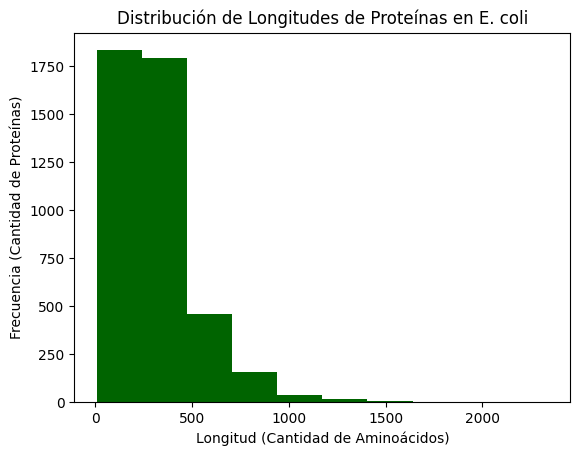

In [70]:
df['longitud'].hist(grid= False, color='darkgreen')
# 2. Le agregamos las etiquetas de texto
plt.title("Distribución de Longitudes de Proteínas en E. coli")
plt.xlabel("Longitud (Cantidad de Aminoácidos)")
plt.ylabel("Frecuencia (Cantidad de Proteínas)")
plt.show()

**Conclusión de la Distribución de Longitudes:**

Al analizar el histograma, se evidencia una clara distribución asimétrica positiva (sesgada a la derecha). La inmensa mayoría de las proteínas de la *E. coli* se concentran en un rango pequeño, de entre 0 a 500 aminoácidos aproximadamente. 

Desde una perspectiva biológica, esto responde a un principio de metabolismo y supervivencia. Como la bacteria necesita dividirse y reproducirse a gran velocidad, prioriza la síntesis de proteínas relativamente chicas, ya que fabricar cadenas muy largas requiere un gasto masivo de energía (ATP) y tiempo. 

Por otro lado, podemos notar una larga "cola" que se extiende hacia la derecha, llegando hasta los 1500/2000 aminoácidos. Estos casos atípicos (outliers) son muy pocos y suelen corresponder a maquinarias estructurales sumamente complejas que la bacteria necesita en menor cantidad.